In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn.preprocessing as skp
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix)


In [2]:
from google.colab import drive
# Read the diabetes dataset
drive.mount('/content/drive')
dataset_path = '/content/drive/MyDrive/DSProject/diabetes.csv'

df=pd.read_csv(dataset_path)
df.head()

Mounted at /content/drive


,Diabetes,HighBP,HighChol,BMI,Smoker,Stroke,Myocardial,PhysActivity,Fruit,Vegetables,...,NotAbleToAffordDoctor,GeneralHealth,MentalHealth,PhysicalHealth,HardToClimbStairs,BiologicalSex,AgeBracket,EducationBracket,IncomeBracket,Zodiac
0,0,1,1,40,1,0,0,0,0,1,...,0,5,18,15,1,1,9,4,3,10
1,0,0,0,25,1,0,0,1,0,0,...,1,3,0,0,0,1,7,6,1,11
2,0,1,1,28,0,0,0,0,1,0,...,1,5,30,30,1,1,9,4,8,2
3,0,1,0,27,0,0,0,1,1,1,...,0,2,0,0,0,1,11,3,6,11
4,0,1,1,24,0,0,0,1,1,1,...,0,2,3,0,0,1,11,5,4,8


In [3]:
# class balance: how many have diabetes vs not (in %)
df['Diabetes'].value_counts(normalize=True)

,proportion
Diabetes,
0,0.860667
1,0.139333


In [4]:
df.info()
df.describe()
# check missing values
df.isna().sum()
df = df.dropna()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype
---  ------                 --------------   -----
 0   Diabetes               253680 non-null  int64
 1   HighBP                 253680 non-null  int64
 2   HighChol               253680 non-null  int64
 3   BMI                    253680 non-null  int64
 4   Smoker                 253680 non-null  int64
 5   Stroke                 253680 non-null  int64
 6   Myocardial             253680 non-null  int64
 7   PhysActivity           253680 non-null  int64
 8   Fruit                  253680 non-null  int64
 9   Vegetables             253680 non-null  int64
 10  HeavyDrinker           253680 non-null  int64
 11  HasHealthcare          253680 non-null  int64
 12  NotAbleToAffordDoctor  253680 non-null  int64
 13  GeneralHealth          253680 non-null  int64
 14  MentalHealth           253680 non-null  int64
 15  PhysicalHealth   

**Socioeconomic Patterns (Income & Education vs Diabetes)**

In [5]:
# avg diabetes rate for each income bracket
income_pivot = df.pivot_table(
    index='IncomeBracket',
    values='Diabetes',
    aggfunc='mean'
)
income_pivot


,Diabetes
IncomeBracket,
1,0.242891
2,0.261903
3,0.223084
4,0.201341
5,0.174014
6,0.145078
7,0.121821
8,0.079604


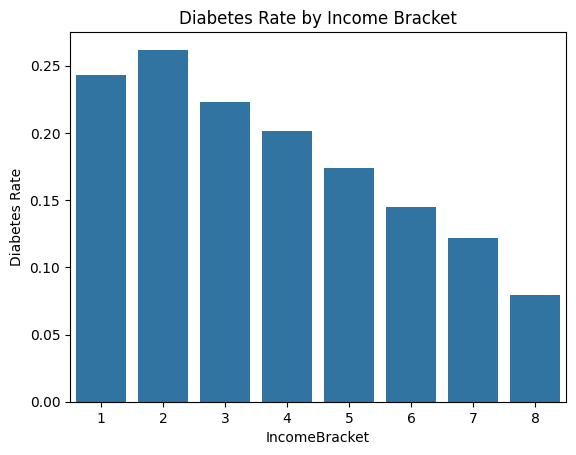

In [6]:
# barplot: diabetes rate by income bracket
sns.barplot(data=income_pivot.reset_index(),
            x='IncomeBracket',
            y='Diabetes')
plt.ylabel('Diabetes Rate')
plt.title('Diabetes Rate by Income Bracket');


The bar plot shows that diabetes rates decrease as income increases. Income brackets 1 and 2 have the highest diabetes rates, and each higher bracket shows a lower rate, with bracket 8 having the lowest. This makes it clear that in this dataset, lower income levels are linked to higher diabetes prevalence.

In [7]:
# avg diabetes rate by education level
edu_pivot = df.pivot_table(
    index='EducationBracket',
    values='Diabetes',
    aggfunc='mean'
)
edu_pivot


,Diabetes
EducationBracket,
1,0.270115
2,0.292605
3,0.242245
4,0.176351
5,0.148105
6,0.096902


This table shows that individuals with lower levels of education in this dataset are more likely to have diabetes. This pattern may be related to factors often linked to education, such as health literacy, access to information about healthy behaviors, job opportunities that influence income, and access to healthcare. It is also notable that Education Bracket 2 has a slightly higher diabetes rate than Bracket 1, which may be worth examining further to understand why this occurs.

In [8]:
# mean BMI and diabetes rate grouped by income
df[['IncomeBracket', 'BMI', 'Diabetes']].groupby('IncomeBracket').agg(['mean'])


,BMI,Diabetes
,mean,mean
IncomeBracket,,
1,29.698094,0.242891
2,29.761181,0.261903
3,29.217394,0.223084
4,28.952818,0.201341
5,28.745238,0.174014
6,28.625418,0.145078
7,28.405424,0.121821
8,27.571942,0.079604


The table shows that both BMI and diabetes rates decrease as income increases. Individuals in the lower income brackets have the highest average BMIs as well as the highest diabetes rates, while higher income groups show lower values for both. This pattern suggests a link between income, weight, and diabetes risk, where higher BMI in lower income groups may contribute to their higher diabetes prevalence. Including BMI in the analysis helps clarify how socioeconomic factors relate to health outcomes in this dataset.

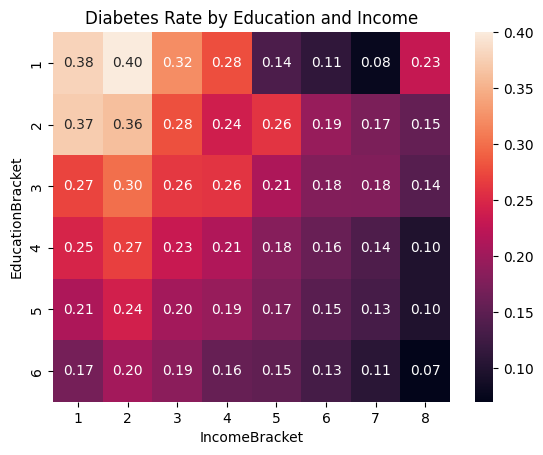

In [9]:
# heatmap: diabetes rate across income x education grid
pivot2 = df.pivot_table(
    index='EducationBracket',
    columns='IncomeBracket',
    values='Diabetes',
    aggfunc='mean'
)
sns.heatmap(pivot2, annot=True, fmt='.2f')
plt.title('Diabetes Rate by Education and Income');


The diabetes heatmap shows a clear socioeconomic pattern. Individuals with lower education and income levels have much higher diabetes rates, with the highest-risk groups appearing in the top-left area of the heatmap. For example, diabetes prevalence reaches 40% among those in the lowest education bracket and the second-lowest income bracket, with similar rates in nearby low-income, low-education groups. In contrast, the lowest diabetes rates appear in the bottom-right, where individuals with the highest education and income levels show prevalence as low as 7 - 10%. This pattern highlights both the individual and combined effects of income and education, since the lowest risk is seen when both are high. Overall, the heatmap demonstrates how socioeconomic status strongly influences health outcomes, with individuals who have fewer educational and financial resources facing a greater burden of diabetes.

**Access to Care**

In [10]:
# diabetes rate by healthcare access + affordability
access_pivot = df.pivot_table(
    index='HasHealthcare',
    columns='NotAbleToAffordDoctor',
    values='Diabetes',
    aggfunc='mean'
)
access_pivot


NotAbleToAffordDoctor,0,1
HasHealthcare,,
0,0.102450,0.135182
1,0.137206,0.186170


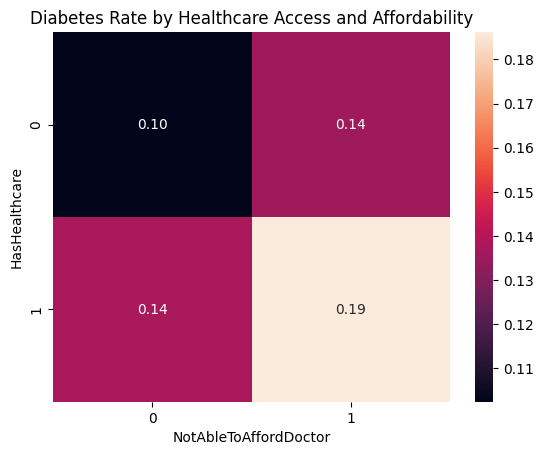

In [11]:
# heatmap for healthcare access variables
sns.heatmap(access_pivot, annot=True, fmt='.2f')
plt.title('Diabetes Rate by Healthcare Access and Affordability');


The heatmap shows how healthcare access and the ability to afford a doctor relate to diabetes prevalence. The highest diabetes rate appears among individuals who have healthcare coverage but cannot afford a doctor, suggesting that insurance alone is not enough when financial barriers prevent people from using it. The lowest rate is found among those without healthcare who can still afford a doctor, highlighting affordability as a strong protective factor. The two remaining groups fall in the middle, with similar rates of 0.14. Together, the patterns in the heatmap indicate that the ability to pay for care plays a more influential role in diabetes risk than simply having healthcare coverage, showing the importance of affordability in shaping health outcomes.

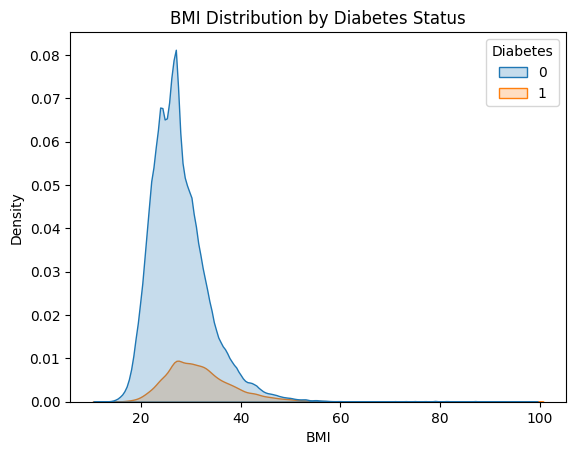

In [12]:
# compare BMI distribution for people with vs without diabetes
sns.kdeplot(data=df, x='BMI', hue='Diabetes', fill=True)
plt.title('BMI Distribution by Diabetes Status');


While both diabetics and non-diabetics share a similar modal BMI, the distribution for diabetics is noticeably right-skewed. This indicates that, compared to non-diabetics, a larger proportion of diabetic individuals fall into higher BMI categories.

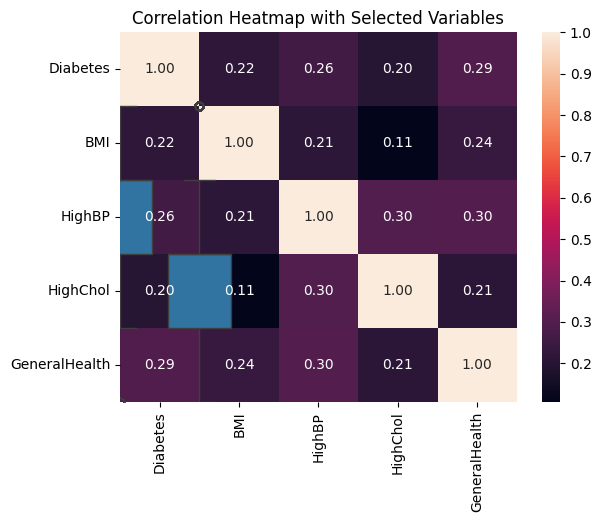

In [13]:
# boxplot: GeneralHealth vs Diabetes status
sns.boxplot(data=df, x='Diabetes', y='GeneralHealth')
plt.title('General Health by Diabetes Status');

# correlation heatmap for key numeric variables
corr_cols = ['Diabetes', 'BMI', 'HighBP', 'HighChol', 'GeneralHealth']
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f')
plt.title('Correlation Heatmap with Selected Variables');


The correlation heatmap shows that Diabetes has moderate positive relationships with GeneralHealth (0.29), HighBP (0.26), BMI (0.22), and HighChol (0.20). This indicates that poorer general health, high blood pressure, higher BMI, and high cholesterol tend to occur alongside diabetes. These patterns are consistent with our other findings and highlight why these variables are important predictors.

In [14]:
## pre‑processing for modeling ##
socio_cols = [
    'IncomeBracket',
    'EducationBracket',
    'HasHealthcare',
    'NotAbleToAffordDoctor',
    'BiologicalSex',
    'AgeBracket'
]

X_socio = df[socio_cols].copy()
y = df['Diabetes']

# label-encode any non-numeric socio columns (same style as L20)
for col in socio_cols:
    if X_socio[col].dtype == 'object':
        X_socio[col] = skp.LabelEncoder().fit_transform(X_socio[col])

# full model: socioeconomic + lifestyle/clinical vars
full_cols = socio_cols + [
    'HighBP',
    'HighChol',
    'BMI',
    'Smoker',
    'Stroke',
    'Myocardial',
    'PhysActivity',
    'Fruit',
    'Vegetables',
    'HeavyDrinker',
    'GeneralHealth',
    'MentalHealth',
    'PhysicalHealth',
    'HardToClimbStairs'
]

X_full = df[full_cols].copy()

scaler = StandardScaler()
num_cols = ['BMI', 'MentalHealth', 'PhysicalHealth']
X_full[num_cols] = scaler.fit_transform(X_full[num_cols])

In [15]:
# stratify=y so class balance is similar in train/test
X_train_socio, X_test_socio, y_train, y_test = train_test_split(
    X_socio, y, test_size=0.2, random_state=42, stratify=y
)

X_train_full, X_test_full, _, _ = train_test_split(
    X_full, y, test_size=0.2, random_state=42, stratify=y
)

**Socioeconomic Only Model**

In [16]:
# logistic regression using only socioeconomic features
model_socio = LogisticRegression(max_iter=1000)
model_socio.fit(X_train_socio, y_train)

y_pred_socio = model_socio.predict(X_test_socio)

acc_socio = accuracy_score(y_test, y_pred_socio)
print('Accuracy:', acc_socio)
print(classification_report(y_test, y_pred_socio))

Accuracy: 0.8604541154210028
              precision    recall  f1-score   support

           0       0.86      1.00      0.92     43667
           1       0.41      0.00      0.01      7069

    accuracy                           0.86     50736
   macro avg       0.63      0.50      0.47     50736
weighted avg       0.80      0.86      0.80     50736



The logistic regression model that uses only socioeconomic features has an accuracy of 0.86, meaning it predicts diabetes status correctly for 86% of individuals overall. However, this accuracy is misleading because the model performs very poorly on the diabetes class. Its precision for predicting diabetes is 0.41, and its recall is 0.00, which shows that it identifies almost none of the individuals who actually have diabetes. As a result, the F1-score for Class 1 is only 0.01. This occurs because the dataset is highly imbalanced, with many more non-diabetic individuals than diabetic ones, so the model defaults to predicting the majority class. Although the macro and weighted averages appear acceptable, the class-specific metrics show that this model is not effective for detecting diabetes when it relies only on socioeconomic variables.

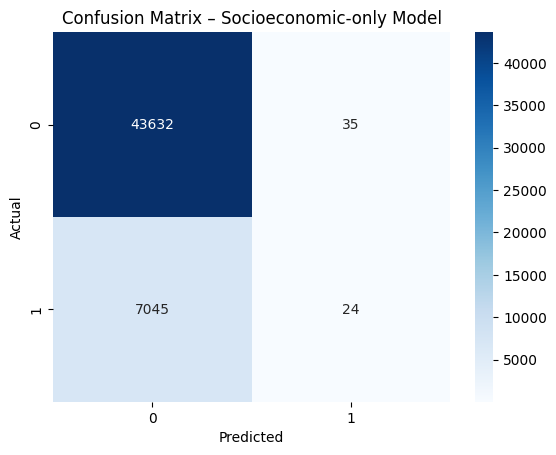

In [17]:
# confusion matrix
cm_socio = confusion_matrix(y_test, y_pred_socio)
sns.heatmap(cm_socio, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix – Socioeconomic-only Model')
plt.xlabel('Predicted')
plt.ylabel('Actual');


The confusion matrix for the socioeconomic-only model highlights its main weaknesses. The model produces a very high number of true negatives (43,632), meaning it correctly identifies most individuals without diabetes. However, it almost completely fails to detect individuals who do have diabetes. It identifies only 24 true positives and misses 7,045 diabetic individuals, resulting in an extremely high false-negative count. This shows that the model is heavily biased toward the majority class. The small number of false positives (35) also confirms that the model predicts “no diabetes” for nearly everyone. Although this leads to high overall accuracy, the model is not able to perform its main task of identifying diabetes cases. This outcome is common in models trained on highly imbalanced datasets without methods that address the minority class.

**Full Features Model**

In [18]:
# logistic regression with all features (socio + health)
model_full = LogisticRegression(max_iter=1000)
model_full.fit(X_train_full, y_train)

y_pred_full = model_full.predict(X_test_full)

acc_full = accuracy_score(y_test, y_pred_full)
print('Accuracy:', acc_full)
print(classification_report(y_test, y_pred_full))

Accuracy: 0.8623068432671082
              precision    recall  f1-score   support

           0       0.88      0.98      0.92     43667
           1       0.52      0.16      0.24      7069

    accuracy                           0.86     50736
   macro avg       0.70      0.57      0.58     50736
weighted avg       0.83      0.86      0.83     50736



The performance metrics for the full-features model show clear improvement compared to the socioeconomic-only model. The accuracy increases slightly to 86.2%, but the more important changes appear in the class-specific metrics. Precision for the diabetes class rises to 0.52, and recall increases to 0.16, meaning the model is now able to correctly identify a larger share of individuals who actually have diabetes. As a result, the F1-score increases to 0.24, showing a better balance between precision and recall. Although these values are still modest, they represent a meaningful improvement in the model’s ability to detect diabetes. Including health and lifestyle features makes the model much more effective than relying on socioeconomic information alone.

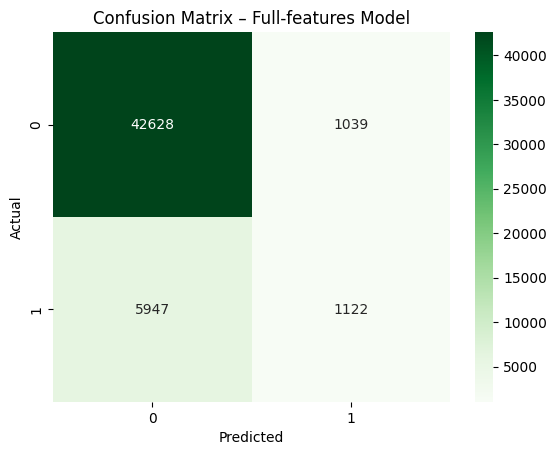

In [19]:
# confusion matrix for full model
cm_full = confusion_matrix(y_test, y_pred_full)
sns.heatmap(cm_full, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix – Full-features Model')
plt.xlabel('Predicted')
plt.ylabel('Actual');


The confusion matrix for the full-features model shows clear improvement over the socioeconomic-only model. True negatives remain high at 42,628, but true positives increase from 24 to 1,122, and false negatives drop from 7,045 to 5,947. This means the model is identifying many more individuals who have diabetes. The downside is that false positives rise from 35 to 1,039, showing that the model predicts diabetes more often, even when incorrect. Overall, the confusion matrix shows that adding health and lifestyle features makes the model much better at detecting diabetes, despite the increase in false positives.

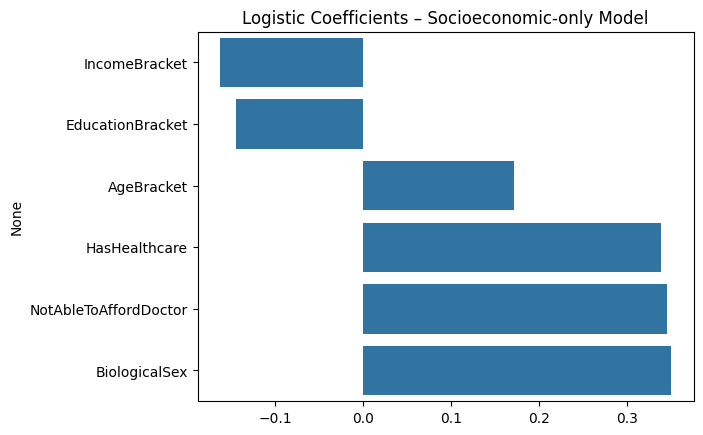

In [20]:
# map coefficients to column names (socio-only)
coef_socio = pd.Series(model_socio.coef_[0], index=socio_cols).sort_values()
coef_socio
# barplot of coefficients for socio-only model
sns.barplot(x=coef_socio.values, y=coef_socio.index)
plt.title('Logistic Coefficients – Socioeconomic-only Model');

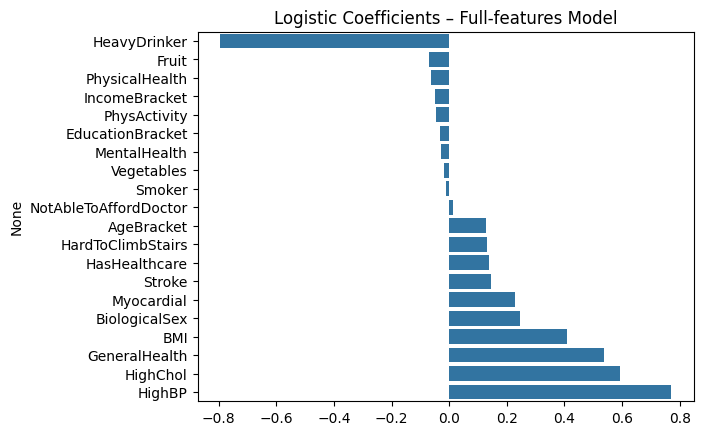

In [21]:
# same idea for full model
coef_full = pd.Series(model_full.coef_[0], index=full_cols).sort_values()
sns.barplot(x=coef_full.values, y=coef_full.index)
plt.title('Logistic Coefficients – Full-features Model');


When the model relies only on socioeconomic features, the strongest predictors of diabetes are biological sex, age, and barriers to healthcare access. Once health and lifestyle variables are added, the model shifts dramatically, with clinical measures becoming the dominant predictors. High blood pressure, high cholesterol, poor self-reported health, and higher BMI have the strongest positive influence on diabetes likelihood. Here socioeconomic variables become far less influential, suggesting that their impact is largely explained through the health conditions and behaviors the full model captures.

In [22]:
#comparison of model performance metrics
import pandas as pd

tp_socio = cm_socio[1, 1]
fp_socio = cm_socio[0, 1]
fn_socio = cm_socio[1, 0]

precision_socio = tp_socio / (tp_socio + fp_socio) if (tp_socio + fp_socio) > 0 else 0
recall_socio = tp_socio / (tp_socio + fn_socio) if (tp_socio + fn_socio) > 0 else 0

tp_full = cm_full[1, 1]
fp_full = cm_full[0, 1]
fn_full = cm_full[1, 0]

precision_full = tp_full / (tp_full + fp_full) if (tp_full + fp_full) > 0 else 0
recall_full = tp_full / (tp_full + fn_full) if (tp_full + fn_full) > 0 else 0

metrics_data = {
    'Model': [
        'Socioeconomic-only', 'Socioeconomic-only', 'Socioeconomic-only',
        'Full-features', 'Full-features', 'Full-features'
    ],
    'Metric': [
        'Accuracy', 'Precision (Class 1)', 'Recall (Class 1)',
        'Accuracy', 'Precision (Class 1)', 'Recall (Class 1)'
    ],
    'Value': [
        acc_socio, precision_socio, recall_socio,
        acc_full, precision_full, recall_full
    ]
}

metrics_df = pd.DataFrame(metrics_data)
print(metrics_df)

                Model               Metric     Value
0  Socioeconomic-only             Accuracy  0.860454
1  Socioeconomic-only  Precision (Class 1)  0.406780
2  Socioeconomic-only     Recall (Class 1)  0.003395
3       Full-features             Accuracy  0.862307
4       Full-features  Precision (Class 1)  0.519204
5       Full-features     Recall (Class 1)  0.158721


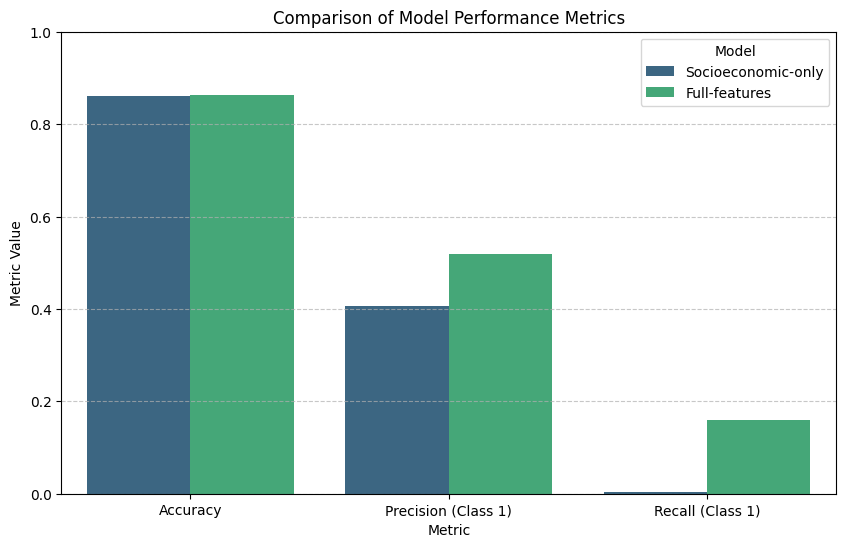

In [23]:
# Vizualizing the comparison of Model Performance metrics
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(data=metrics_df, x='Metric', y='Value', hue='Model', palette='viridis')
plt.title('Comparison of Model Performance Metrics')
plt.ylabel('Metric Value')
plt.xlabel('Metric')
plt.ylim(0, 1) # Metrics are between 0 and 1
plt.legend(title='Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The comparison of the performance metrics shows an important difference between the socioeconomic-only and full-features models. Both have similar overall accuracy at around 0.86, which demonstrates that accuracy alone can be misleading with imbalanced data. The full-features model has higher precision and a much better recall for diabetes, meaning it identifies far more actual cases. This indicates that adding health and lifestyle features greatly improves the model’s ability to detect the minority class, making it more useful for identifying individuals who may need further evaluation or intervention.